## DeepISA tutorial

DeepISA is an end-to-end Python package for training DNA sequence models and quantifying transcription factor (TF) importance and cooperativity across the genome. It uses a dilated convolutional neural network to predict log-transformed functional assay signals (e.g., CAGE-seq, ATAC-seq, DNase-seq, SuRE-seq, STARR-seq) from the DNA sequences of candidate regulatory elements (CREs). 

The package then performs In Silico Ablation (ISA), which computationally masks specific TF binding motifs and measures how individual or combined motif removal changes predicted regulatory activity. By comparing these effects, DeepISA places TF interactions on a continuum from redundancy to synergy, revealing consistent principles of gene regulation.

TODO:  because deepISA generate large files, it always write minibatches directly to hard disk. You can load back the result and play with it later.

To run the deepISA pipeline, you need to prepare the following files to run the deepISA pipeline:


1. Mandatory Genomic Resources

* Reference Genome (.fa): A FASTA file of the genome (the tutorial uses hg38). This is required to convert genomic locations to actual sequences

* TF Binding Annotations (.bb): Specifically, JASPAR 2026 genome-wide predictions in bigBed format. This allows the tool to know where the transcription factor motifs are located for ablation.


2. Primary Input Data: regulatory region and signal

You need your candidate regulatory regions and their activity levels. You have two main ways to provide this:

* Option A (Pre-quantified): A CSV or BED file containing genomic coordinates (chrom, start, end) and a column with pre-calculated signal intensities (e.g., TPM or read counts from CAGE-seq). Make sure that the signal intensity is NOT log-transformed.

* Option B (BigWig signal Tracks): A BED file of coordinates plus the corresponding BigWig (.bw) files. The pipeline will then quantify the signals for you.


3. Optional Enrichment Data

* ReMap 2022 (.bed): A curated atlas of ChIP-seq peaks. You use this if you want to filter your results to only include motifs that have ChIP-Seq evidence of binding in a specific cell type.

* Expressed TF List: A list of TFs known to be active in your cell line. This is highly recommended to reduce false positives by ensuring you only analyze TFs that are actually present.

4. Pre-trained Model (Alternative to Training):

* Weights File (.pt): If you don't want to train a new model from scratch, you can provide a pre-trained PyTorch model (like the model_blympho.pt mentioned) to go straight to the In Silico Ablation (ISA) analysis.

## Basic imports and data loading

Prepare the following files for the deepISA pipeline:

* Reference genome: [hg38](https://hgdownload.cse.ucsc.edu/goldenpath/hg38/bigZips/hg38.fa.gz)

* Jaspar: [JASPAR 2026](https://mencius.uio.no/JASPAR/JASPAR_TFBSs/2026/JASPAR2026_hg38.bb) is genome-wide predictions of TF binding sites in bigBed format for hundreds of TFs, based on high-quality TF Position Frequency Matrices. Other versions (JASPAR 2022, 2024) may cause compatibility issues.

* ReMap (optional): [ReMap 2022](https://remap.univ-amu.fr/storage/remap2022/hg38/MACS2/remap2022_nr_macs2_hg38_v1_0.bed.gz) is a curated atlas of 182 million DNA-TF binding peaks, derived from 8103 human ChIP-seq datasets, covering hundreds of TFs across hundreds of cell lines and tissues.

In [1]:
import os
from loguru import logger
import pandas as pd
from deepISA.utils import get_data_resource
from deepISA.utils import find_available_gpu


FASTA_PATH = "/maps/projects/ralab/people/pcr980/Resource/hg38.fa"
JASPAR_BB = "/maps/projects/ralab/people/pcr980/Resource/JASPAR/JASPAR2026_hg38.bb"
CELL_FACET = "B_lymphoblastoid"
SEQ_LEN = 600
DEVICE=find_available_gpu()
MODE="dual"


/maps/projects/ralab/people/pcr980/miniforge3/envs/genome_gpu/lib/python3.10/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
2026-04-24 16:59:54.993 | INFO     | deepISA.utils:find_available_gpu:86 - Using GPU 0: NVIDIA H100 NVL (93.09 GB)


## QuickStart, the fast track

regions_pos.bed comes containing randomly selected 1000 candidate regulatory regions with CAGE signal, for B_lymphoblastoid cell line. 

Subsetting regulatory regions aims to accelerate training for tutorial. The model performance is supposed to improve with full set of regulatory regions.

On output file names:
* "motif_": information about individual TF binding sites
* "tf_": TF features aggregated from all binding sites
* "_t0": track_idx. 

In [ ]:
# Step 1: load data, train a regression model with classification regularization
bed_path = get_data_resource("regions_pos_with_count.csv")
df_regions = pd.read_csv(bed_path)
df_regions.head()


In [ ]:
from deepISA.quickstart import QuickStart

pipe = QuickStart(
    results_dir="./QuickStart_regression",
    fasta_path=FASTA_PATH,
    df_input=df_regions, # regions to analyze, negative region is optional
    device=DEVICE,
)

In [ ]:
# This is default parameters for model configuration
model_config = {
    "seq_len": SEQ_LEN,
    "ks": [15,9,9,9,9], # kernel size
    "cs": [64,64,64,64,64], # channel size
    "ds": [1,2,4,8,16],
    "dropout": 0.1
}

pipe.define_model(model_config, mode=MODE)



In [ ]:

# This is default parameters for trainer configuration
trainer_config={
    "epochs": 10,
    "batch_size": 128,
    "patience": 5,
    "min_delta": 0.001, # minimum change in the monitored metric to qualify as an improvement
    "learning_rate": 1e-3,
    "save_one_fourth": False,
    "save_one": False
}


# specify the column in df_regions that contains the signal, the regression prediction target
# make sure this column is not log-transformed, as deepISA will apply log transformation internally
pipe.train(trainer_config, 
           target_reg_col="target_reg")

pipe.load_checkpoint("best")

In [ ]:
# This is default parameters for isa_config
isa_config = {
    "expressed_tfs": None,
    "motif_score_threshold": 500,
    "subset_by_remap": False,
    "remap_path": None,
    "min_count":10,
    "num_regions_per_batch": 400,
    "pred_batch_size": 8192,
    "attr_percentile": 50,
    "attr_batch_size": 1024,
    "min_count":10,
    "q_val_thresh":0.1,
    "inde_dist_min":100,
    "inde_dist_max":255 # receptive field.
}

pipe.run_isa(
    jaspar_path=JASPAR_BB,
    isa_config=isa_config
)

pipe.report() 

While `jaspar_path` is the only required argument for `.run_isa()`, providing a list of `expressed_tfs` is highly recommended for biological relevance. By passing a list of TFs known to be expressed in your specific cell line, the model filters out motifs of TFs that aren't present and therefore cannot be functional. We also provide function `get_expressed_tfs()` to estimate expressed TF list from the candidate regions and genome-wide bigwig signals. See section _____ for more information.

Variations of QuickStart usage:
* If you only have the regions and a bigwig file, but you haven't quantified it yourself, we can quantify it for you (also see section _____), just privide the bw_path in `.train()`.

* If you have a pretrained model already, just provide the model path, and we start from `.run_isa()`.

In [ ]:
# If you have a pretrained model:
import torch
from deepISA.quickstart import QuickStart

pipe = QuickStart(
    results_dir="./QuickStart_pretrained",
    fasta_path=FASTA_PATH,
    df_input=df_regions,
    device=DEVICE,
)


In [ ]:
from deepISA.modeling.cnn import Conv
# load pretrained model
pretrained_model_path = get_data_resource("model_blympho.pt") 
pretrained_model=Conv(mode=MODE, model_config=model_config)
pretrained_model.load_state_dict(torch.load(pretrained_model_path, weights_only=False))

pipe.define_model(model_obj=pretrained_model, mode=MODE)
# Skip .train()
pipe.run_isa(jaspar_path=JASPAR_BB, isa_config=isa_config)

pipe.report()

## Details of workflow: step by step

Let's disect the workflow that QuickStart wraps up.

In [2]:
# set up logger to save logs in the results directory
from deepISA.utils import setup_logger
from deepISA.modeling.preprocess import compile_training_data
from deepISA.utils import get_data_resource

RESULTS_DIR = "Step_by_step_res"
os.makedirs(RESULTS_DIR, exist_ok=True)

setup_logger(RESULTS_DIR)
logger.info("Starting deepISA tutorial")


2026-04-24 17:00:04 | INFO     | setup_logger:132 - Logger initialized. Logs redirected to: Step_by_step_res/workflow.log
2026-04-24 17:00:04 | INFO     | <module>:10 - Starting deepISA tutorial


### 1. Prepare data for deep learning

This step uses function `compile_training_data()`. It takes in your BED file as a `pandas.DataFrame` and returns labeled data for downstream deep learning.

The input DataFrame must include the following column names:

* "chrom": chromosome identifier
* "start": start coordinate
* "end": end coordinate

Ensure that all intervals satisfy: end - start == target_input_length

Multiple preprocessing workflows are supported. You may either provide pre-quantified data (option 1), or use the built-in labeling function, simply by passing additional arguments to `compile_training_data()` (option 2).

#### Option 1: BED file with pre-quantified signals

Use this mode if your have already quantified the signals (e.g., TPM or read counts) for the candidate regions. The pipeline will automatically sample non-functional background regions to balance the dataset, so that number of positive and negative regions equalize.

These background regions are sampled genome-wide, excluding candidate Cis-Regulatory Elements ([cCREs](https://www.nature.com/articles/s41586-025-09909-9)), exons and the ENCODE blacklist.

Make sure that your quantified signals are not log-transformed, since compile_training_data() will automatically perform log transformation. Hence, the model will always output log-transformed signal predictions.

By default, `rc_aug==True`, to apply reverse complement data augmentation. This is highly recommended for stable training, unless you are training on strand-aware data like single-stranded CAGE-Seq signals.

In [ ]:
# read an internal example file
df_pos = pd.read_csv(get_data_resource("regions_pos_with_count.csv"))
df_pos.head()

In [ ]:
df_data = compile_training_data(
    df=df_pos, 
    fasta_path=FASTA_PATH,
    out_dir =os.path.join(RESULTS_DIR, "Data"),
    seq_len=SEQ_LEN,
    # your column name for TPM/count/signal, make sure it is not log transformed.
    target_reg_col="target_reg",
    rc_aug=True # Highly recommended, unless you are training on single strand CAGE data.
)
df_data.head() 

One columns are is added by function `compile_training_data()`: 
* "target_class": classification target, 1 for positive regions (regulatory elements), 0 for negative regions.

In [ ]:
# define model:
from deepISA.modeling.cnn import Conv

model_cfg = {
    'seq_len': SEQ_LEN, # make sure this is the same as in compile_training_data
    'ks': [15,9,9,9,9],
    'cs': [64,64,64,64,64],
    'ds': [1, 2, 4, 8, 16]
}

model = Conv(
    mode=MODE, # Can be 'regression', or 'dual'
    model_config=model_cfg
)

print(model)

#### Option 2: BED file + BigWig signal tracks

If you have genomic coordinates of regulatory elements, and want to quantify signals directly from BigWig files. The pipeline estimates a noise threshold from background regions to define the classification target.

Just pass a list of bigwig file paths to the optional parameter `bw_paths`.
  

### 2 Train convolutional neural network

This step uses function `train_model()`. It takes in the labeled data frame, performs train-val-test split, then train a exponentially dilated convolutional neural network. The main architecture highly resembles BPNet, but doesn't contain the per-base profile prediction for faster training.

Early stopping is enabled by default, so it is design to "overfit" the validation set. Use `evaluate_model()` to get the unbiased performance estimate.

For hyperparameter tuning, `train_model()` will automatically save a "training_log.csv" to record the learning curve.


In [ ]:
from deepISA.modeling.train import train_model

trainer_config={
    "epochs": 10,
    "batch_size": 128,
    "patience": 5,
    "min_delta": 0.001, # minimum change in the monitored metric to qualify as an improvement
    "learning_rate": 1e-3,
    "save_one_fourth": False,
    "save_one": False
}

train_model(
    model=model,
    device=DEVICE,
    train_dat_dir=os.path.join(RESULTS_DIR, "Data"), # the directory compile_training_data outputs to
    mode=MODE,
    model_dir=os.path.join(RESULTS_DIR, "Model"),
    trainer_config=trainer_config
)

In [ ]:
# load back the model 

### 3. Map motifs for all candidate regulatory regions with positive signal

This step uses function `map_motif()`. It takes in the candidate regulatory regions with positive signal, and returns all the motif locations according to [JASPAR 2026](https://mencius.uio.no/JASPAR/JASPAR_TFBSs/2026/JASPAR2026_hg38.bb) database, thresholded by motif matching score, for each regulatory region. 

The JASPAR matching score (range: 100-1000) quantifies how well a short DNA sequence aligns with a transcription factor motif from the JASPAR database, using a position weight matrix to compute a similarity score at each position. The default Jaspar score is 500, meaning the p-value of motif matching is 1e-5.

In [ ]:
from deepISA.scoring.mapper import map_motifs
import torch
#TODO: write preprocess_remap(cell_type). 

# load the best model
model_path = os.path.join(RESULTS_DIR, "Model", "model_best.pt")
model.load_state_dict(torch.load(model_path, weights_only=True))

map_motifs(
    regions_df=df_pos, 
    fasta_path=FASTA_PATH,
    jaspar_path=JASPAR_BB,
    outpath=os.path.join(RESULTS_DIR,"motif_locs.csv"),
    model=model,
    device=DEVICE,
    tracks=[0],
    expressed_tfs=None, # set to None for tutorial, but providing expressed_tf_list is highly recommended for real analysis to reduce false positives.
    motif_score_thresh=500,
    remap_path=None,
    attr_percentile=70,
    attr_batch_size=1024
)


# read the mapped motif locations
df_motif_locs = pd.read_csv(os.path.join(RESULTS_DIR,"motif_locs.csv"))
df_motif_locs.head()

attribution filter

One way to reduce false positive of TF binding site is to retain only those with overlapping ChIP-Seq peak recorded in [ReMap 2022](https://remap2022.univ-amu.fr/) database. It is essentially a giant bed file containing genomic locations of ChIP-Seq peak for thousands of TFs in hundreds of cell lines. By setting `remap_path=YOUR_REMAP_PATH`, function `map_motif()` will return an additional column "remap_evidence" of boolean values, indicating whether each motif is supported by the ChIP-Seq peak of the same TF according to ReMap. Then you can subset manually to contain only the motifs supported by ChIP-Seq.

However, not all TFs expressed in each cell line have a corresponding ChIP-Seq experiment, thus subsetting by ReMap evidence risks losing valid TF binding sites simply due to lack of ChIP-Seq experiment recorded in ReMap.

A more lenient motif filtering strategy: filtering by TF gene expression level since only expressed TFs can exert influence. By passing `expressed_tfs=YOUR_EXPRESSED_TF_LIST`, function `map_motif()` will only return the motifs of TFs in the `expressed_tfs`.

In [ ]:
from deepISA.scoring.infer_tf_expr import get_expressed_tfs

# Define the same BigWig tracks used for training
bw_paths = [
    f"{BW_DIR}/{CELL_FACET}.minus.bw", 
    f"{BW_DIR}/{CELL_FACET}.plus.bw"
]

# Infer the list of expressed TFs based on a noise threshold
expressed_tf_list = get_expressed_tfs(
    bw_paths=bw_paths, 
    percentile=99
)

len(expressed_tf_list)

### 4. Run single ISA to quantify TF importance

This step first uses function `run_single_isa()`. It takes in a well-trained model and the filtered motif locations, and output the in silico ablation scores of all motifs directly to hard disk. This step is computation heavy, thus GPU is necessary here. 

Then we use function `calc_tf_importance()` to aggregate all the motif ISA scores for each TF. Aggregation methods include mean, median and signed Kolmogorov-Smirnov (KS) statistics. KS requires sufficient instances for accurate calculation, thus it produces a warning if fewer than 5 instances exist for a TF.

In [ ]:
from deepISA.scoring.single_isa import run_single_isa, calc_tf_importance

# 3. Compute Single-Motif ISA
run_single_isa(
    model=model, 
    fasta_path=FASTA_PATH,
    motif_locs_path=os.path.join(RESULTS_DIR, "motif_locs.csv"),
    outpath=os.path.join(RESULTS_DIR, "motif_single_isa.csv"),
    device=DEVICE,
    num_regions_per_batch=200, # Adjust based on your GPU memory, larger batch size will speed up the process but use more memory
    pred_batch_size=1024,
)

df_single_isa = pd.read_csv(os.path.join(RESULTS_DIR, "motif_single_isa.csv"))
df_single_isa.head()

In [ ]:
# 4: aggregate single ISA to yield tf importance

single_isa_path = os.path.join(RESULTS_DIR, "motif_single_isa.csv")
tf_importance = calc_tf_importance(single_isa_path,min_count=10)
tf_importance.head()
# Save the final summary
tf_importance.to_csv(os.path.join(RESULTS_DIR, "tf_importance.csv"), index=False)


### 5. Run combinatorial ISA for TF pair cooperativity

This step first uses function `run_combi_isa()`. It takes in a well-trained model, the filtered motif locations, and model receptive field. Then it performs combinatorial ISA for all motifs on same regulatory region within distance of the model receptive field. Models trained by deepISA package have attribute `.rf` for receptive field.

Then we use function `calc_coop_score()` to aggregate the raw combinatorial ISA results and obtain cooperativity score. Note, this aggregation can be performed on both TF-pair and TF level, by specifying `level='tf_pair'`, or `level='tf_pair'`. 

In the cooperativity score report, TF pairs are always alphabetically sorted and concatenated by "|".

In [ ]:
from deepISA.scoring.combi_isa import run_combi_isa


run_combi_isa(
    model=model,
    fasta_path=FASTA_PATH,
    motif_locs_path=os.path.join(RESULTS_DIR, "motif_locs.csv"),
    outpath=os.path.join(RESULTS_DIR, "motif_combi_isa.csv"),
    device=DEVICE,
    inde_dist_max=model.rf, # make sure this is the same as the receptive field of your model
    num_regions_per_batch=200,
    pred_batch_size=1024
)


In [ ]:
from deepISA.scoring.combi_isa import  calc_coop_score

combi_isa_path = os.path.join(RESULTS_DIR, "motif_combi_isa.csv")
outpath_pair = os.path.join(RESULTS_DIR, "coop_tf_pair.csv")
calc_coop_score(combi_isa_path,
                outpath_pair,
                level="tf_pair",
                inde_dist_min=100,
                inde_dist_max=model.rf,
                min_count=10,
                q_val_thresh=0.1)

outpath_tf = os.path.join(RESULTS_DIR, "coop_tf.csv")
calc_coop_score(combi_isa_path,
                outpath_tf,
                level="tf",
                inde_dist_min=100,
                inde_dist_max=model.rf,
                min_count=10,
                q_val_thresh=0.1)


### 6. Plot results

deepISA package provide deepCompARE style analysis and plots, for reproducibility and sanity check.

In [3]:
# load result data
import os
import pandas as pd
RESULTS_DIR = "Step_by_step_res"
df_raw_combi = pd.read_csv(os.path.join(RESULTS_DIR, "motif_combi_isa.csv"))
df_coop_pair = pd.read_csv(os.path.join(RESULTS_DIR, "coop_tf_pair.csv"))
df_coop_tf = pd.read_csv(os.path.join(RESULTS_DIR, "coop_tf.csv"))

#### Observation 1: interaction decays along distance

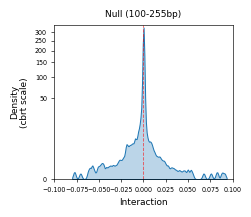

In [4]:
from deepISA.plotting.interaction import (
    plot_null,
    plot_interaction_decay, 
)

plot_null(df_raw_combi)

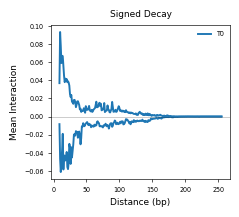

In [5]:
plot_interaction_decay(df_raw_combi)

#### Observation 2: TF-pair level cooperativity 

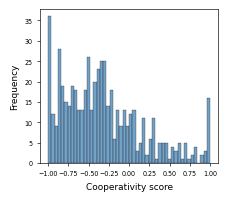

In [6]:
from deepISA.plotting.cooperativity import (
    hist_coop_score,
    heatmap_coop_score,
    plot_motif_distance_by_category
)

hist_coop_score(df_coop_pair)

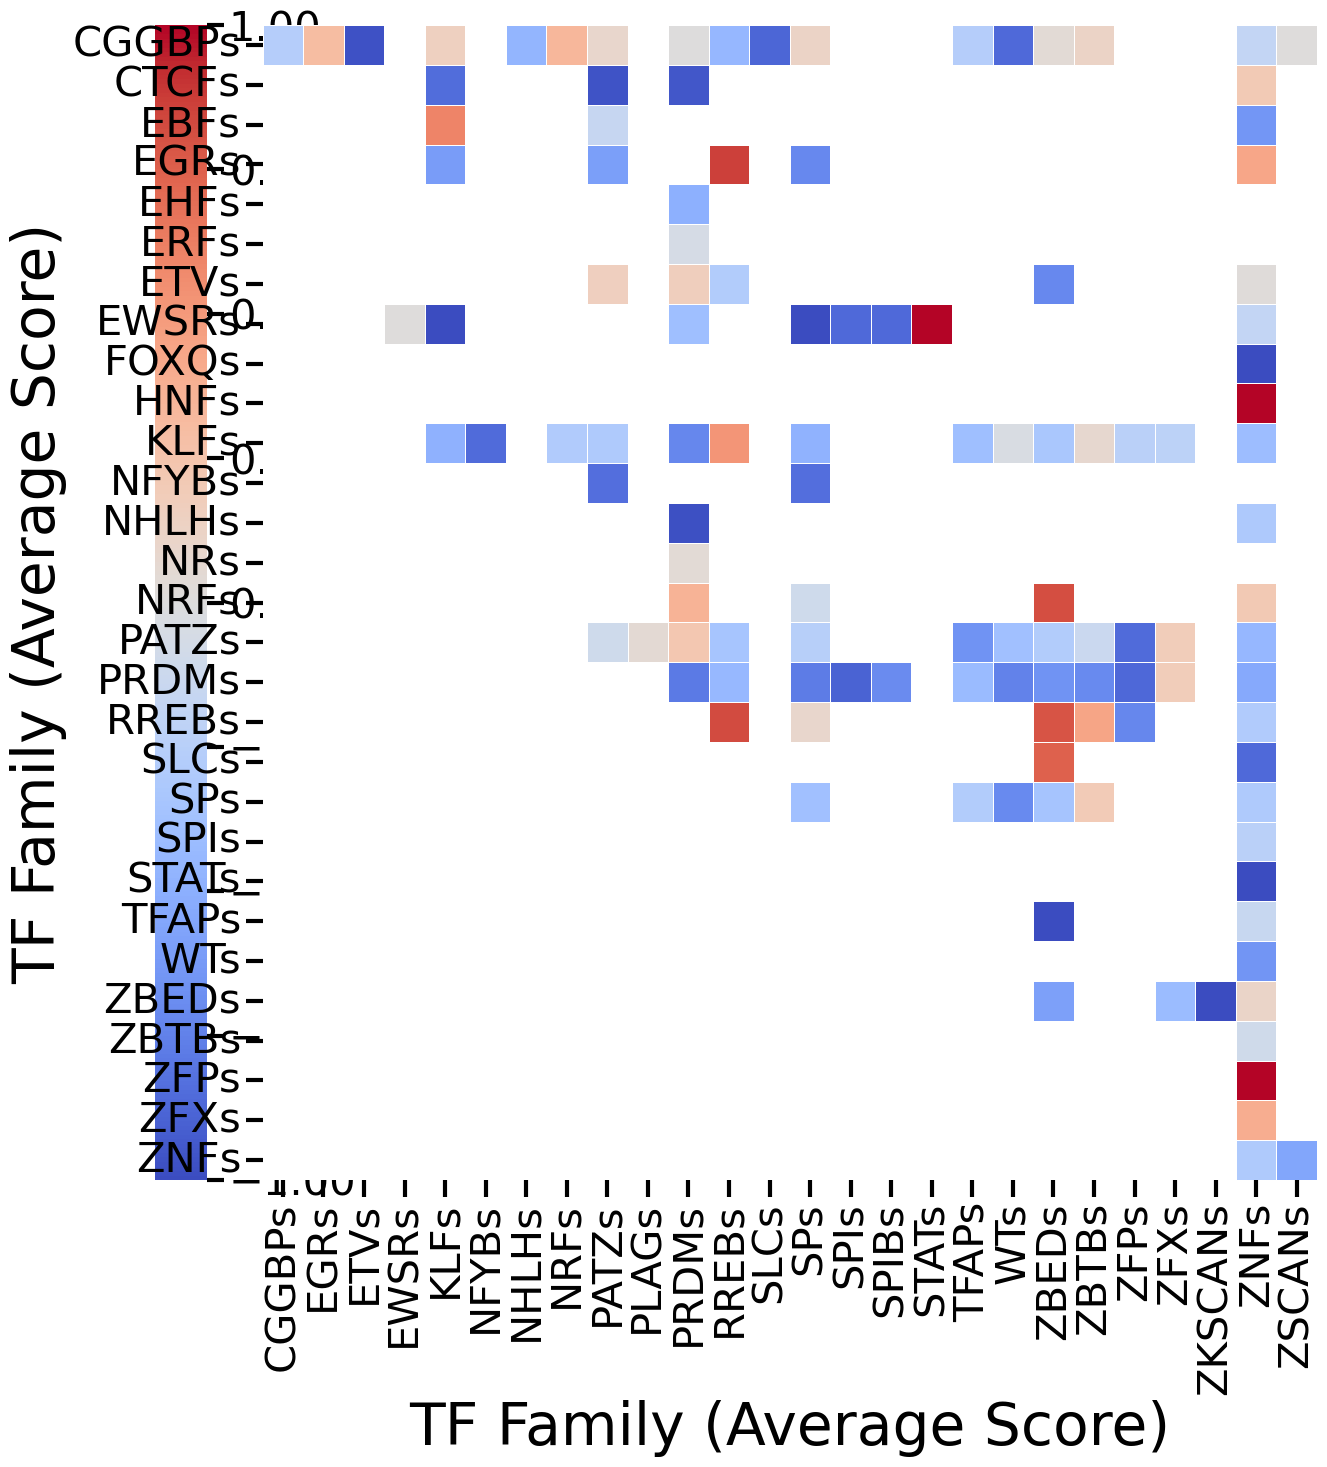

In [7]:
# Height for labels can be set based on max frequency
heatmap_coop_score(df_coop_pair)

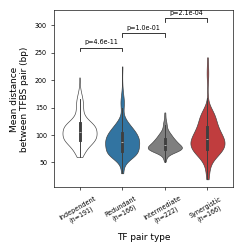

In [8]:
plot_motif_distance_by_category(df_coop_pair)

#### Observation 3: TF level cooperativity

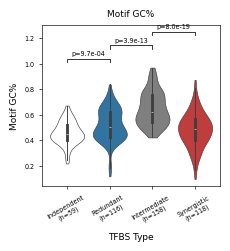

In [9]:
from deepISA.plotting.tf import (
    plot_motif_gc_by_coop,
    plot_coop_vs_importance,
    plot_partner_specificity
)

df_coop_tf = pd.read_csv(os.path.join(RESULTS_DIR, "coop_tf.csv"))
plot_motif_gc_by_coop(df_coop_tf)

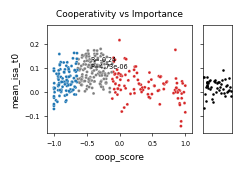

In [10]:
# Plot cooperativity score vs importance score 
df_importance = pd.read_csv(os.path.join(RESULTS_DIR, "tf_importance.csv"))
plot_coop_vs_importance(df_coop_tf, df_importance)

/maps/projects/ralab/people/pcr980/DeepCompare/deepISA/src/deepISA/plotting/tf.py:124: RuntimeWarning: invalid value encountered in scalar divide
  return group.sort_values('abs_i_sum', ascending=False).head(top_n)['abs_i_sum'].sum() / group['abs_i_sum'].sum()


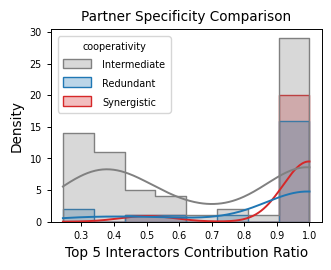

In [11]:
plot_partner_specificity(df_coop_pair, df_coop_tf,min_partners=1)

### 7. Explore association with external data

Tell user dimers "::" are removed from PPI validation.
Only for human

#### Observation 4: TF family behavior

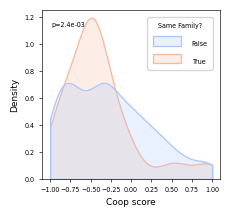

In [12]:
from deepISA.exploring.tf_family import (
    plot_coop_by_tf_pair_family,
    plot_coop_by_dbd,
    plot_intra_family_coop_score
)

df_res=plot_coop_by_tf_pair_family(df_coop_pair)

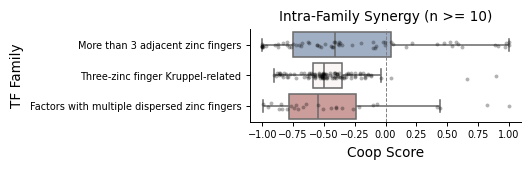

In [13]:
df_res=plot_intra_family_coop_score(df_coop_pair)

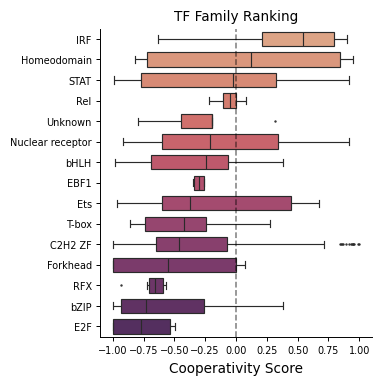

In [14]:
df_res=plot_coop_by_dbd(df_coop_tf)

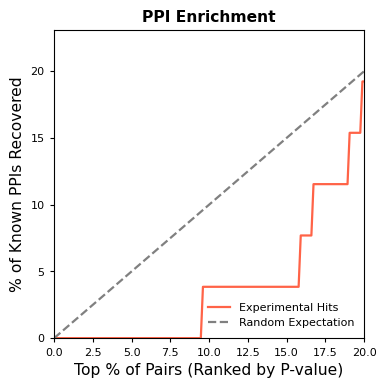

In [15]:
from deepISA.exploring.tf_pair_ppi import (
    plot_ppi_enrichment,
    plot_cofactor_recruitment,
    plot_dna_mediated_ppi
)


df_res = plot_ppi_enrichment(df_coop_pair)

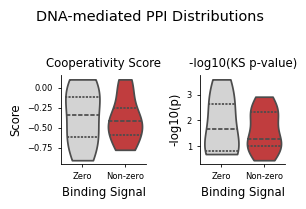

In [16]:
plot_dna_mediated_ppi(df_coop_pair)

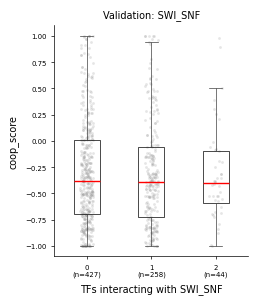

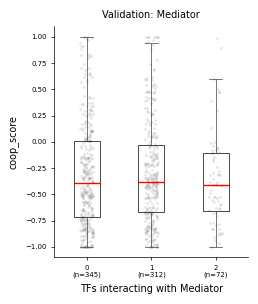

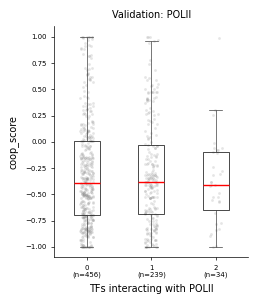

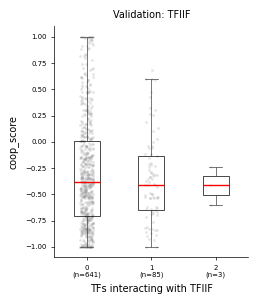

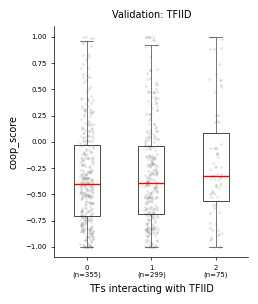

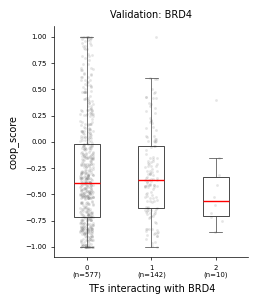

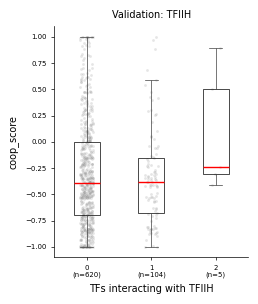

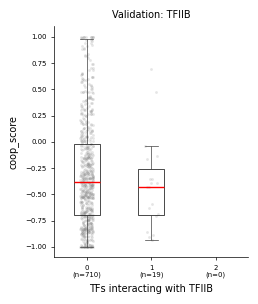

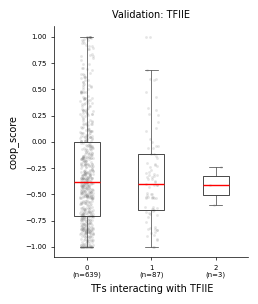

In [17]:
# Cooperativity between TF pairs of same family
df_res=plot_cofactor_recruitment(df_coop_pair)

Validate with TF functions: gini index and known TF functional categories.

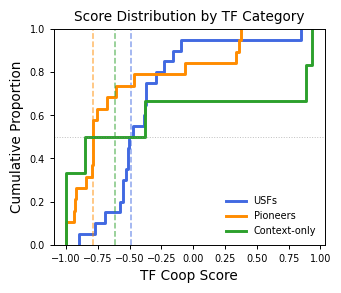

In [18]:
from deepISA.exploring.tf_function import (
    plot_usf_pfs,
    plot_cell_specificity
)

plot_usf_pfs(df_coop_tf)

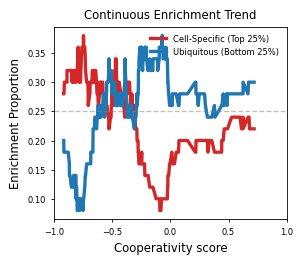

In [19]:
plot_cell_specificity(df_coop_tf)